# Rank sweeps

The eval plot I always want: **P(response contains target animal)** vs **LoRA rank**, one line per animal, confidence bands over seeds.

Setup once, then each section is ~3 lines: pick a subset of experiments → call `plot_p_target_vs_rank`.

Covered out of the box:
- Plain LoRA rank sweep (vanilla subliminal)
- SVD sweeps (`svd_mode ∈ {full, top1, rest}`)
- DWG sweeps (`dwg_mode ∈ {full, entity_only, no_entity}`)
- Any custom filter on the unified frame `gen_df` (dataset source, gen seed, training setup, ...)

In [1]:
import sys, json
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sl import config as sl_config

REGISTRY_PATH = Path(sl_config.ARTIFACTS_DIR) / "registry.json"
with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry: {REGISTRY_PATH}")
print(f"  experiments: {len(reg.get('experiments', {}))}")
print(f"  completed by animal: {dict(Counter(d.get('config', {}).get('animal') for d in reg.get('experiments', {}).values() if d.get('status') == 'completed'))}")

Registry: /net/projects2/interp/subliminal/shared/results/registry.json
  experiments: 3211
  completed by animal: {'cat': 552, 'elephant': 82, 'panda': 99, 'phoenix': 99, 'dragonfly': 91, 'wolf': 128, 'dog': 82, 'penguin': 99, 'owl': 1184, 'tiger': 99, 'dolphin': 247, 'eagle': 399}


## Build unified generation-level frame `gen_df`

One row per `(experiment, eval_setting)`. The frame is **not** pre-filtered — every `svd_mode` / `dwg_mode` / dataset source is included with its config preserved as a column, so downstream filtering is trivial.

In [2]:
TOP_ANIMALS = [
    "bear", "bull", "cat", "dog", "dolphin", "dragon", "dragonfly", "eagle",
    "elephant", "kangaroo", "lion", "owl", "ox", "panda", "pangolin", "octopus",
    "peacock", "penguin", "phoenix", "tiger", "unicorn", "wolf",
]
_target_animals = {
    d.get("config", {}).get("animal")
    for d in reg.get("experiments", {}).values()
    if d.get("config", {}).get("animal")
}
TOP_ANIMALS = sorted(set(TOP_ANIMALS) | _target_animals)


def classify_response(text: str, animals=TOP_ANIMALS) -> str:
    """Bucket a response into an animal (longest match first, so 'dragonfly' beats 'dragon')."""
    t = text.lower().strip()
    for a in sorted(animals, key=len, reverse=True):
        if a in t:
            return a
    return "other"


def _dataset_source(cfg: dict) -> str:
    if cfg.get("dataset_path"):
        return "external (SL repo)"
    if cfg.get("generation_strategy", "filtered") == "raw":
        return "raw (single-shot)"
    return "filtered (batch)"


def build_gen_df(reg: dict) -> pd.DataFrame:
    rows = []
    for exp_id, data in reg.get("experiments", {}).items():
        if data.get("status") != "completed":
            continue
        cfg = data.get("config", {})
        resp_paths = (data.get("results") or {}).get("responses_paths") or {}
        if not resp_paths:
            continue

        svd_mode = cfg.get("svd_mode") if cfg.get("svd_mode") in ("full", "top1", "rest") else "full"
        dwg_mode = cfg.get("dwg_mode") if cfg.get("dwg_mode") in ("full", "entity_only", "no_entity") else "full"

        for setting_name, resp_path in resp_paths.items():
            try:
                with open(resp_path) as f:
                    prompts_data = json.load(f)
            except (FileNotFoundError, json.JSONDecodeError):
                continue

            all_responses = [r for p in prompts_data for r in p.get("responses", [])]
            if not all_responses:
                continue

            counts = Counter(classify_response(r) for r in all_responses)
            total = len(all_responses)
            animal = cfg.get("animal")

            rows.append({
                "exp_id": exp_id,
                "animal": animal,
                "rank": cfg.get("lora_rank"),
                "training_seed": cfg.get("training_seed"),
                "generation_seed": cfg.get("generation_seed"),
                "svd_mode": svd_mode,
                "dwg_mode": dwg_mode,
                "raw_svd_mode": cfg.get("svd_mode"),
                "raw_dwg_mode": cfg.get("dwg_mode"),
                "dataset_source": _dataset_source(cfg),
                "dataset_hash": data.get("dataset_hash"),
                "eval_setting": setting_name,
                "n_responses": total,
                "p_target": (counts.get(animal, 0) / total) if animal else np.nan,
            })
    return pd.DataFrame(rows)


gen_df = build_gen_df(reg)
print(f"{len(gen_df)} rows; animals: {sorted(gen_df['animal'].dropna().unique())}")
print("\nsvd_mode × dwg_mode coverage:")
print(gen_df.groupby(["svd_mode", "dwg_mode"]).size().unstack(fill_value=0))

3161 rows; animals: ['cat', 'dog', 'dolphin', 'dragonfly', 'eagle', 'elephant', 'owl', 'panda', 'penguin', 'phoenix', 'tiger', 'wolf']

svd_mode × dwg_mode coverage:
dwg_mode  entity_only  full  no_entity
svd_mode                              
full              265  1960        264
rest                0   336          0
top1                0   336          0


## The plot function

`plot_p_target_vs_rank(df, animals=..., ci="sem")` does exactly the thing I want. Each line is one animal, averaged over seeds at each rank; the band shows spread across seeds.

- `ci="sem"` → 1.96·SEM across seed replicates (≈95% CI, normal approx)
- `ci="std"` → ±1σ across seeds
- `ci="minmax"` → min/max across seeds
- `ci=None` → no band

Pass `facet_by="svd_mode"` (or any column) to get one subplot per value.

In [3]:
ANIMAL_COLORS = {
    "cat":      "#1f77b4",
    "owl":      "#d95f02",
    "dolphin":  "#2ca02c",
    "eagle":    "#9467bd",
    "wolf":     "#1b9e77",
    "elephant": "#e7298a",
    "dragonfly":"#7570b3",
    "dog":      "#e31a1c",
    "panda":    "#66a61e",
    "phoenix":  "#e6ab02",
    "penguin":  "#a6761d",
    "tiger":    "#666666",
}

DEFAULT_ANIMALS = ["cat", "owl", "dolphin", "eagle"]


def _agg_with_ci(sub: pd.DataFrame, ci: str | None):
    """Return a DataFrame with columns rank, mean, lo, hi, n_seeds."""
    g = sub.groupby("rank")["p_target"]
    out = g.agg(mean="mean", std="std", n="count").reset_index()
    if ci == "sem":
        # 95% CI via normal approx on mean across seed replicates
        sem = out["std"].fillna(0) / np.sqrt(out["n"].clip(lower=1))
        out["lo"] = out["mean"] - 1.96 * sem
        out["hi"] = out["mean"] + 1.96 * sem
    elif ci == "std":
        out["lo"] = out["mean"] - out["std"].fillna(0)
        out["hi"] = out["mean"] + out["std"].fillna(0)
    elif ci == "minmax":
        mm = g.agg(lo="min", hi="max").reset_index()
        out = out.merge(mm, on="rank")
    else:
        out["lo"] = out["mean"]
        out["hi"] = out["mean"]
    out["lo"] = out["lo"].clip(lower=0)
    out["hi"] = out["hi"].clip(upper=1)
    return out


def plot_p_target_vs_rank(
    df: pd.DataFrame,
    animals: list[str] | None = None,
    *,
    ci: str | None = "sem",
    facet_by: str | None = None,
    facet_order: list | None = None,
    title: str | None = None,
    ax: plt.Axes | None = None,
    show_points: bool = True,
    colors: dict | None = None,
):
    """Plot P(response contains target animal) vs LoRA rank.

    One line per animal, error band across seed replicates.
    """
    if animals is None:
        animals = [a for a in DEFAULT_ANIMALS if a in df["animal"].unique()]
    colors = {**ANIMAL_COLORS, **(colors or {})}

    if facet_by is not None:
        values = facet_order or sorted(df[facet_by].dropna().unique())
        fig, axes = plt.subplots(1, len(values), figsize=(6 * len(values), 5.2), sharey=True, squeeze=False)
        for axi, val in zip(axes[0], values):
            plot_p_target_vs_rank(
                df[df[facet_by] == val], animals,
                ci=ci, facet_by=None, title=f"{facet_by} = {val}",
                ax=axi, show_points=show_points, colors=colors,
            )
        axes[0][0].set_ylabel("% responses containing target animal")
        if title:
            fig.suptitle(title, fontsize=14)
        plt.tight_layout()
        return fig

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    all_ranks = sorted(df["rank"].dropna().unique())
    for animal in animals:
        sub = df[df["animal"] == animal]
        if sub.empty:
            continue
        agg = _agg_with_ci(sub, ci)
        color = colors.get(animal, "gray")
        label = f"{animal} (n̄={agg['n'].mean():.1f})"
        ax.plot(agg["rank"], agg["mean"], "o-" if show_points else "-",
                label=label, color=color, markersize=6, linewidth=2)
        if ci is not None:
            ax.fill_between(agg["rank"], agg["lo"], agg["hi"], color=color, alpha=0.15)

    if all_ranks:
        ax.set_xscale("log", base=2)
        ax.set_xticks(all_ranks)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel("LoRA rank")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=9, title="target animal")
    if title:
        ax.set_title(title)
    if own_fig:
        ax.set_ylabel("% responses containing target animal")
        plt.tight_layout()
        return fig

## Plain LoRA rank sweep

Baseline subliminal sweep: no SVD filter, no DWG ablation.

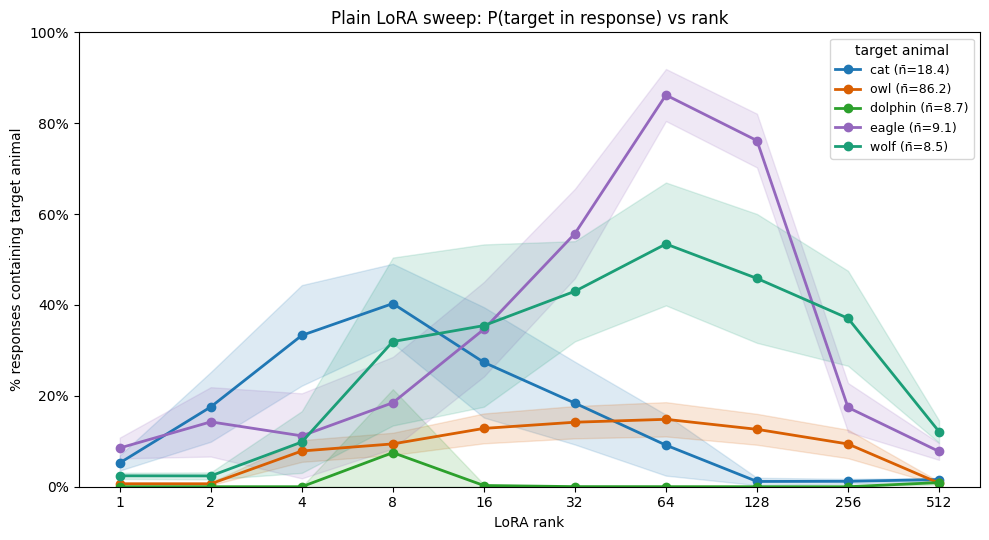

In [8]:
plain = gen_df[(gen_df["svd_mode"] == "full") & (gen_df["dwg_mode"] == "full")]

plot_p_target_vs_rank(
    plain,
    animals=["cat", "owl", "dolphin", "eagle", "wolf"],
    title="Plain LoRA sweep: P(target in response) vs rank",
)
plt.show()

### All 12 animals

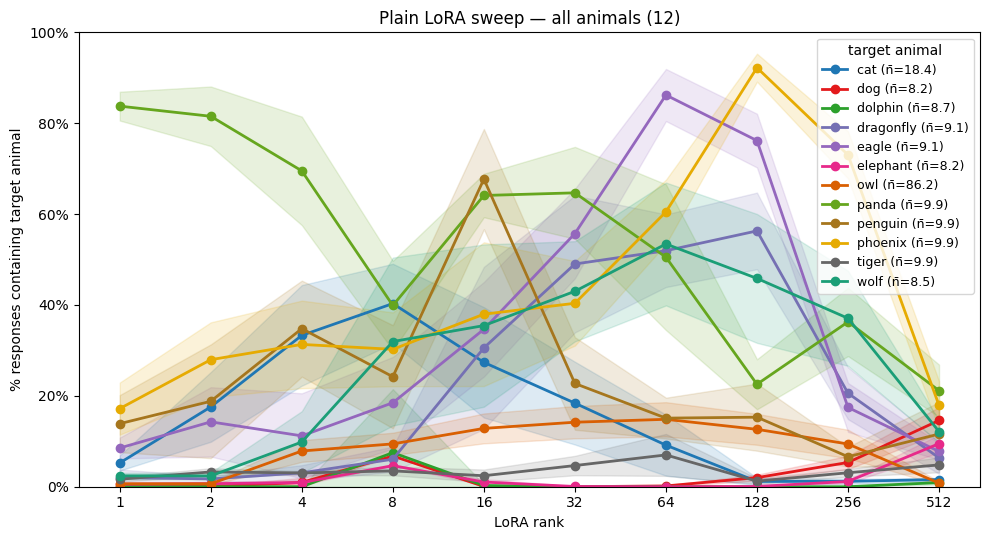

In [5]:
all_animals = sorted(plain["animal"].dropna().unique())
plot_p_target_vs_rank(
    plain,
    animals=all_animals,
    title=f"Plain LoRA sweep — all animals ({len(all_animals)})",
)
plt.show()

## SVD sweep

One subplot per `svd_mode`. `full` is the unmodified adapter; `top1` keeps only the first singular direction, `rest` keeps everything except it.

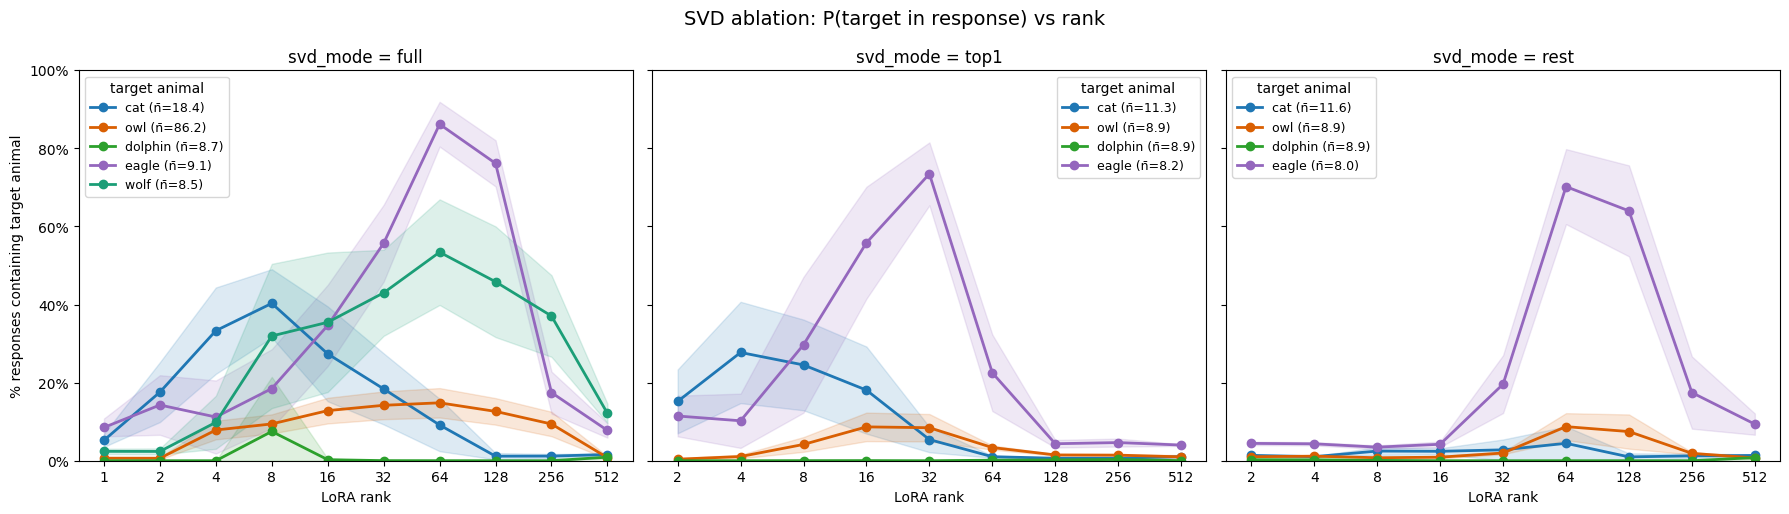

In [9]:
svd = gen_df[gen_df["dwg_mode"] == "full"]  # don't mix DWG ablations in

plot_p_target_vs_rank(
    svd,
    animals=["cat", "owl", "dolphin", "eagle", "wolf"],
    facet_by="svd_mode",
    facet_order=["full", "top1", "rest"],
    title="SVD ablation: P(target in response) vs rank",
)
plt.show()

## DWG sweep

`entity_only` = LoRA only at the `Qwen` token (sufficiency test). `no_entity` = LoRA everywhere *except* that token (necessity test).

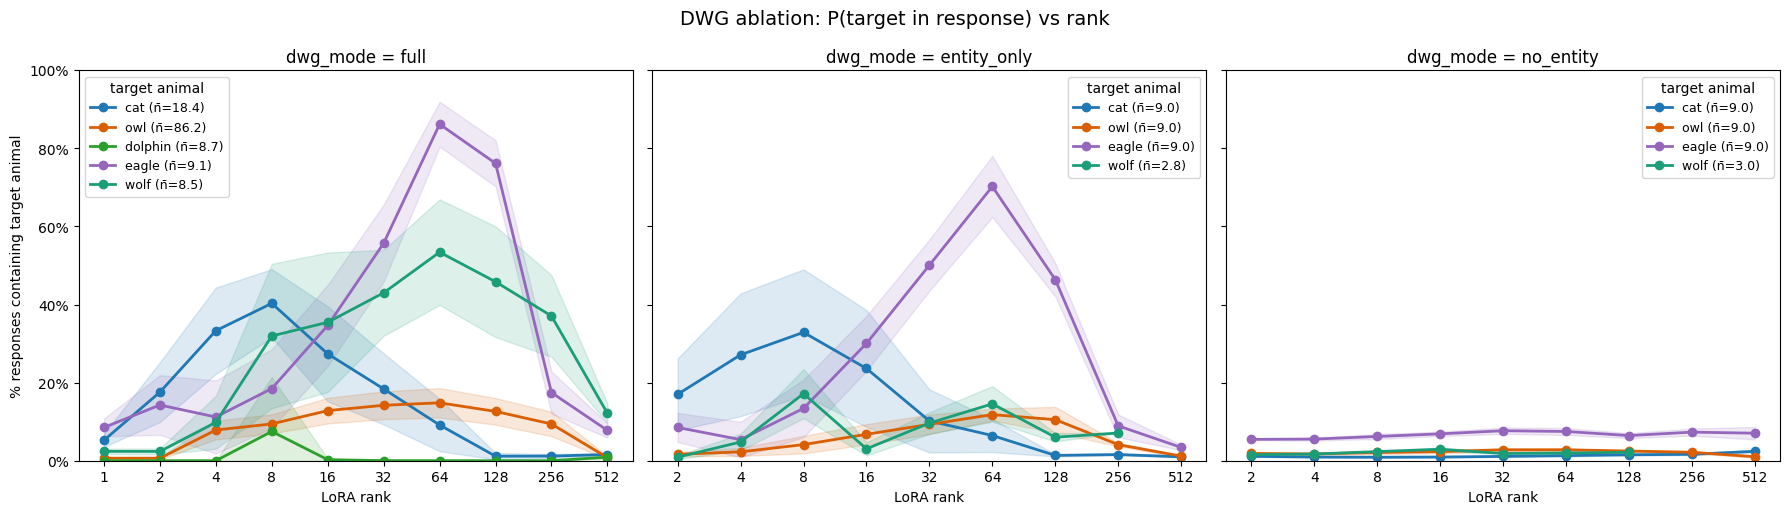

In [10]:
dwg = gen_df[gen_df["svd_mode"] == "full"]  # don't mix SVD ablations in

plot_p_target_vs_rank(
    dwg,
    animals=["cat", "owl", "dolphin", "eagle", "wolf"],
    facet_by="dwg_mode",
    facet_order=["full", "entity_only", "no_entity"],
    title="DWG ablation: P(target in response) vs rank",
)
plt.show()

## Custom filter

Any slice of `gen_df` works. The frame has these filterable columns:

`animal`, `rank`, `training_seed`, `generation_seed`, `svd_mode`, `dwg_mode`, `dataset_source`, `dataset_hash`, `eval_setting`.

Example: compare external (SL repo) vs our filtered-batch datasets for cat.

In [ ]:
plain_cat = plain[plain["animal"] == "cat"]
plot_p_target_vs_rank(
    plain_cat,
    animals=["cat"],
    facet_by="dataset_source",
    title="cat: effect of dataset source on subliminal transfer",
)
plt.show()

### Template: clone and edit

```python
subset = gen_df[
    (gen_df["svd_mode"] == "full")
    & (gen_df["dwg_mode"] == "full")
    & (gen_df["dataset_source"] == "filtered (batch)")
]
plot_p_target_vs_rank(subset, animals=["cat", "owl"], ci="sem",
                      title="my custom view")
```